<a href="https://colab.research.google.com/github/fredstridsh/gestamp_ml/blob/main/Supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Stamping Defects with Supervised Learning

This notebook will introduce you to predict stamping defects. It simulates production where **micro-cracks appears on the stamped chassis components**. To understand what is causing it, you have installed sensors on the press to capture data for each part produced.

The goal here is to:
1. **Understand** what patterns in the sensor data separate good parts from defective ones
2. **Train** a machine learning model to predict defects based on sensor readings
3. **Identify** which machine parameters are causing the issues so engineers can act on them

The four sensor readings captured for every stamped part are:

| Sensor | Unit | What it measures |
|---|---|---|
| `Furnace_Temp_C` | °C | Temperature of the blank before transfer |
| `Transfer_Time_s` | seconds | Time between furnace exit and press contact |
| `Press_Force_t` | tonnes | Peak clamping force applied by the press |
| `Cooling_Flow_Lpm` | L/min | Cooling water flow rate through the die |

> **Note:** The data and the scenario are both synthetic (i.e., computer-generated). We all work with the same numbers, and the results are fully reproducible. Please note that this is meant as an introductory exercise, and both the model and the results are simplified to make the lessons more digestible.

## Step 1: Generate the Dataset
First, we import all the packages needed to run the code. Here, pandas and numpy are for data wrangling and generation, seaborn and matplotlib.pyplot are for data visualization, and sklearn contains the models.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

random_seed = 4
np.random.seed(random_seed) # this will make the results reproducable
n_samples = 10000 # Generate 10000 stamped parts

# Sensor readings, generated from a normal distribution
furnace_temp       = np.random.normal(900, 15, n_samples)   # µ = 900°C, σ = 15°C
transfer_time      = np.random.normal(6, 1.5, n_samples)    # µ = 6°C, σ = 1.5°C
press_force        = np.random.normal(1200, 50, n_samples)  # µ = 1200 tonnes, σ = 50 tonnes
cooling_water_flow = np.random.normal(40, 5, n_samples)     # µ = 40 litres/minute, σ = 5 litres/minute

# Calculate risk score
# Low furnace temp    → steel not hot enough     (890 °C)          → higher risk
# High transfer time  → steel cools too much     (7.5 s)           → higher risk
# High press force    → excess stress            (1250  tonnes)    → higher risk

defects = []
for i in range(n_samples):
    risk_score = (
        (furnace_temp[i] < 890)   * 1.5 +
        (transfer_time[i] > 7.5)  * 2.0 +
        (press_force[i] > 1250)   * 1.0
    )
    if risk_score + np.random.normal(0, 0.8) > 2.5:     # Adding noise to score
        defects.append(1)   # Defect
    else:
        defects.append(0)   # OK

# Gather the data into a DataFrame (2D data structure, think excel sheet)
data = pd.DataFrame({
    'Furnace_Temp_C':   furnace_temp,
    'Transfer_Time_s':  transfer_time,
    'Press_Force_t':    press_force,
    'Cooling_Flow_Lpm': cooling_water_flow,
    'Defect_Flag':      defects
})

print(f"Dataset created with {len(data)} stamped parts.")
print(f"Total defects found: {data['Defect_Flag'].sum()} ({data['Defect_Flag'].mean()*100:.1f}% defect rate)")
display(data.head())

Dataset created with 10000 stamped parts.
Total defects found: 1171 (11.7% defect rate)


,Furnace_Temp_C,Transfer_Time_s,Press_Force_t,Cooling_Flow_Lpm,Defect_Flag
0,900.758426,8.994068,1203.073125,44.171330,0
1,907.499270,7.714241,1224.187861,47.938614,0
2,885.061366,5.363932,1179.232176,44.072309,0
3,910.403978,6.010920,1204.927494,39.009960,0
4,893.725477,6.356315,1247.615182,48.071365,0


## Step 2: Explore the Data

Look at the data before we start modeling.

Here, we want to answer three questions:
- **1) How balanced is the dataset?** (Are defects rare?)
- **2) What does each sensor reading look like?** (Patterns?)
- **3) Can we already see visual separation between OK parts and defective ones?** (Occam's razor)

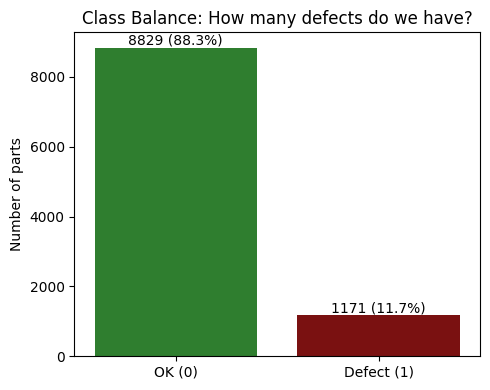


WHY WE CARE:
If defects are rare (e.g. <5%), a model that simply predicts 'OK' for every part
would be 95% accurate, and completely useless. Remember this 


In [38]:
# --- 1 DATASET BALANCE ---
counts = data['Defect_Flag'].value_counts()
labels = ['OK (0)', 'Defect (1)']

plt.figure(figsize=(5, 4))

# Create the barplot
ax = sns.barplot(
    x=labels,
    y=counts.values,
    palette=['forestgreen', 'darkred'],
    hue=labels,
    legend=False
)

plt.title('Class Balance: How many defects do we have?')
plt.ylabel('Number of parts')

# Add text annotations using the captured axes
for i, v in enumerate(counts.values):
    ax.text(i, v + 80, f'{v} ({v/n_samples*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()
print("""
WHY WE CARE:
If defects are rare (e.g. <5%), a model that simply predicts 'OK' for every part
would be 95% accurate, and completely useless. Remember this """)

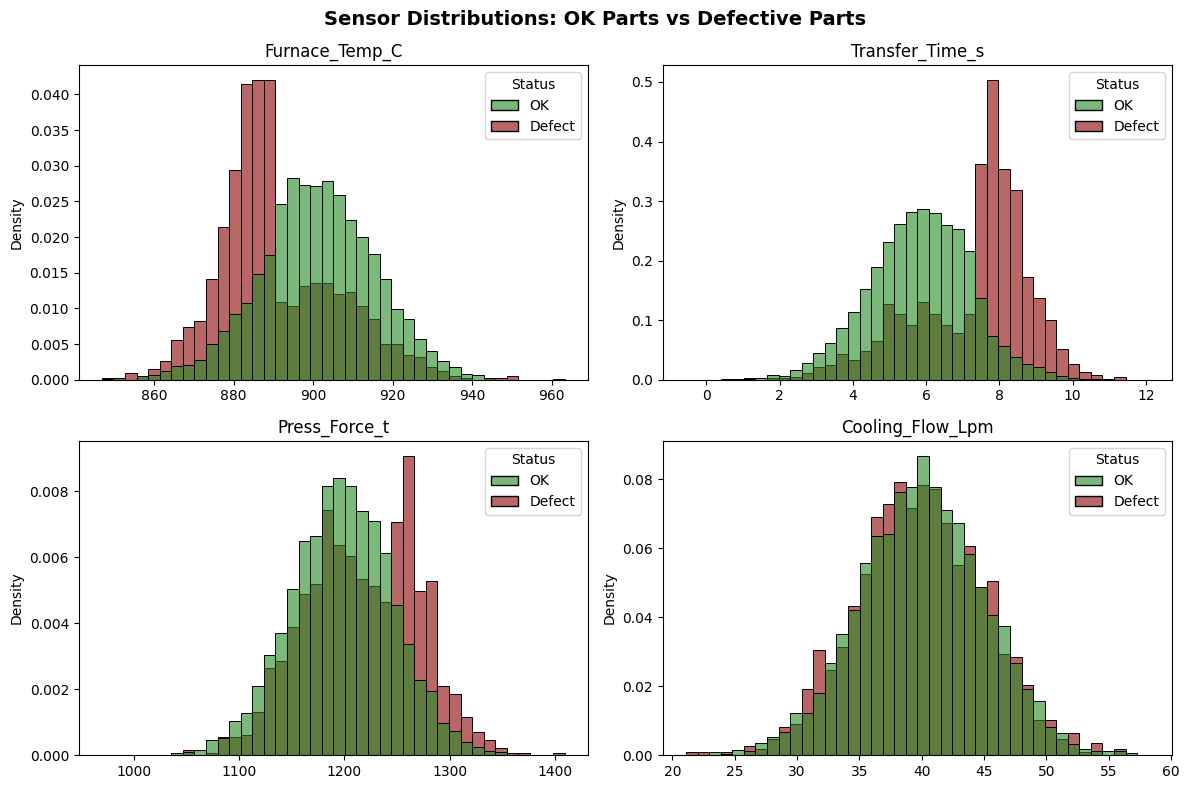


OBSERVATION:
Look at which sensors show clear separation between the red and green distributions.
Those are your likely root causes. Hopefully, your model will confirm this later. 
One of the sensors show virtually no difference between failed and OK chassis, which one?



In [43]:
# --- 2 WHAT EACH SENSOR READING LOOKS LIKE ---
# Features (sensors)
features = ['Furnace_Temp_C', 'Transfer_Time_s', 'Press_Force_t', 'Cooling_Flow_Lpm']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Create a temporary column to map the binary flags to readable legend labels
plot_data = data.copy()
plot_data['Status'] = plot_data['Defect_Flag'].map({0: 'OK', 1: 'Defect'})

for i, col in enumerate(features):
    sns.histplot(
        data=plot_data,
        x=col,
        hue='Status',
        bins=40,
        stat='density',
        common_norm=False,  # Ensures each group's density is calculated independently
        palette={'OK': 'forestgreen', 'Defect': 'darkred'},
        alpha=0.6,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_ylabel('Density')
    axes[i].set_xlabel('') # Clears the x-axis label for a cleaner look

fig.suptitle('Sensor Distributions: OK Parts vs Defective Parts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
OBSERVATION:
Look at which sensors show clear separation between the red and green distributions.
Those are your likely root causes. Hopefully, your model will confirm this later.
One of the sensors show virtually no difference between failed and OK chassis, which one?
""")

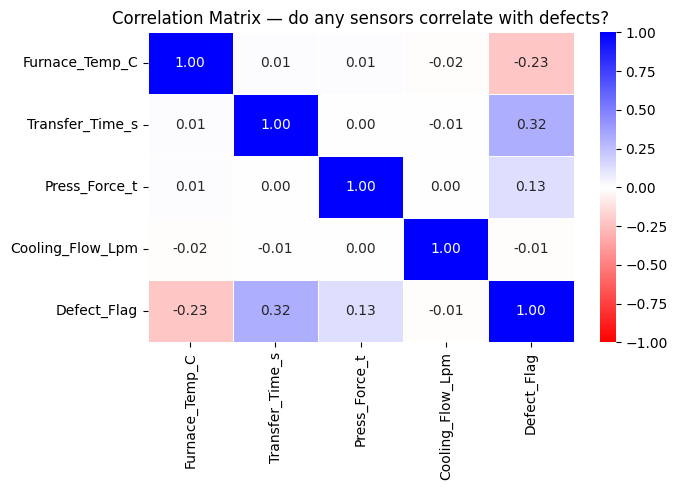


OBSERVATION:
Look at the bottom row (or rightmost column) to see how each sensor linearly correlates with Defects.
Does it agree with what you saw in 2?  Notice how one sensor has virtually zero correlation (-0.01) with defects, 
confirming it has no impact on the outcome. Which one is it?



In [53]:
# --- 3 CORRELATION HEATMAP ---
# Investigate what sensors correlates with what

plt.figure(figsize=(7, 5))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='bwr_r', center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix — do any sensors correlate with defects?')
plt.tight_layout()
plt.show()

print("""
OBSERVATION:
Look at the bottom row (or rightmost column) to see how each sensor linearly correlates with Defects.
Does it agree with what you saw in 2? Notice how one sensor has virtually zero correlation (-0.01) with defects,
confirming it has no impact on the outcome. Which one is it?
""")


## Step 3: Prepare the Data for Modelling

We have now analyzed the data to gain a better intuitive understanding of it. This is possible here due to the manageable number of features. For datasets containing hundreds of features, alternative approaches to exploratory data analysis may be required (see i.e., https://doi.org/10.1111/apha.14219 and https://doi.org/10.1002/sam.10031).

In [57]:
# Separate Features (X) from the Target (y)
X = data.drop('Defect_Flag', axis=1)
y = data['Defect_Flag']

# Split: 80% for training, 20% for testing (common split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seed
)

# Scale the features (sensor readings) to median 0 and standard deviation 1.
# Required by Logistic Regression, and does no harm to later models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training on {len(X_train)} parts, testing on {len(X_test)} parts.")

Training on 8000 parts, testing on 2000 parts.


## Step 4: Logistic Regression

Always begin with a simple model. As we are working with a **binary Target** (OK vs. Defective) we decide to go with Logistic Regression. We do this to establish a **baseline**, telling us what "good enough to be worth bothering" looks like. It is transparent, fast, and a useful sanity check.

LOGISTIC REGRESSION — BASELINE
Accuracy: 89.80%

              precision    recall  f1-score   support

          OK       0.91      0.98      0.94      1781
      Defect       0.59      0.22      0.32       219

    accuracy                           0.90      2000
   macro avg       0.75      0.60      0.63      2000
weighted avg       0.88      0.90      0.88      2000



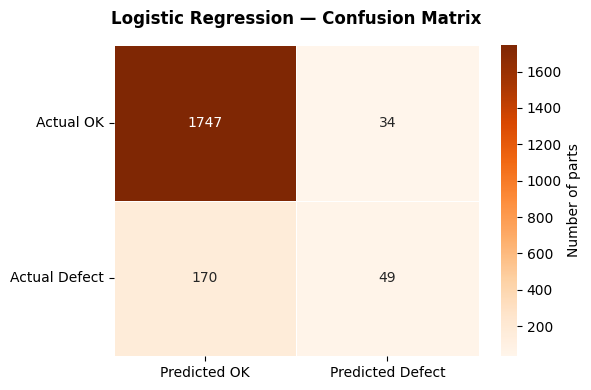

In [66]:
lr_model = LogisticRegression(random_state=random_seed, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("=" * 53)
print("LOGISTIC REGRESSION — BASELINE")
print("=" * 53)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print()
print(classification_report(y_test, y_pred_lr, target_names=['OK', 'Defect']))

# Calculate the confusion matrix using your Logistic Regression predictions
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Plot it using Seaborn
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Predicted OK', 'Predicted Defect'],
    yticklabels=['Actual OK', 'Actual Defect'],
    linewidths=0.5,
    cbar_kws={'label': 'Number of parts'}
)

plt.title('Logistic Regression — Confusion Matrix', pad=15, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("""
HOW TO READ THE CONFUSION MATRIX:

  Top-left  (True Negative):  Parts correctly identified as OK.          →  the goal
  Top-right (False Positive): OK parts incorrectly flagged as defective  → false alarm, wasted scrap
  Bot-left  (False Negative): Defective parts missed by the model        → danger, escapes to customer
  Bot-right (True Positive):  Defects correctly caught                   → the goal
""")

## Step 5: Why Accuracy Alone Is Misleading

You may have noticed we are printing a **classification report** with several metrics, not just accuracy.
Here is why this matters in a manufacturing context:

| Metric | Formula | What it means in our case |
|---|---|---|
| **Accuracy** | Correct predictions / Total | Overall % right — *misleading if defects are rare* |
| **Precision** | True Defects / All Flagged as Defect | Of parts we flag, what fraction are actually bad? |
| **Recall** | True Defects / All Actual Defects | Of all bad parts, what fraction do we catch? |
| **F1-Score** | Harmonic mean of Precision & Recall | Balanced single number |

**For a safety-critical part, missing a defect (low recall) is far worse than a false alarm (low precision).**
A scrapped good part costs you one part. A defective part reaching the customer can cost a recall.

Keep this trade-off in mind as you compare models below.

## Step 6: Decision Tree

Think of it as an automated flowchart. Starting from your full dataset, it repeatedly asks yes/no questions about one sensor at a time — *"Is the furnace temperature below 890°C?"* — splitting the data at each step into increasingly pure groups of OK vs. Defect.

**Key parameters:**
- `max_depth` — how many questions deep the tree is allowed to go. Too deep → memorises training data (overfitting). We will demonstrate this below.

What sensor is the decision tree asking about first? What sensor is in the last step?

DECISION TREE (max_depth=4)
Accuracy: 92.35%

              precision    recall  f1-score   support

          OK       0.93      0.99      0.96      1781
      Defect       0.81      0.39      0.53       219

    accuracy                           0.92      2000
   macro avg       0.87      0.69      0.74      2000
weighted avg       0.92      0.92      0.91      2000



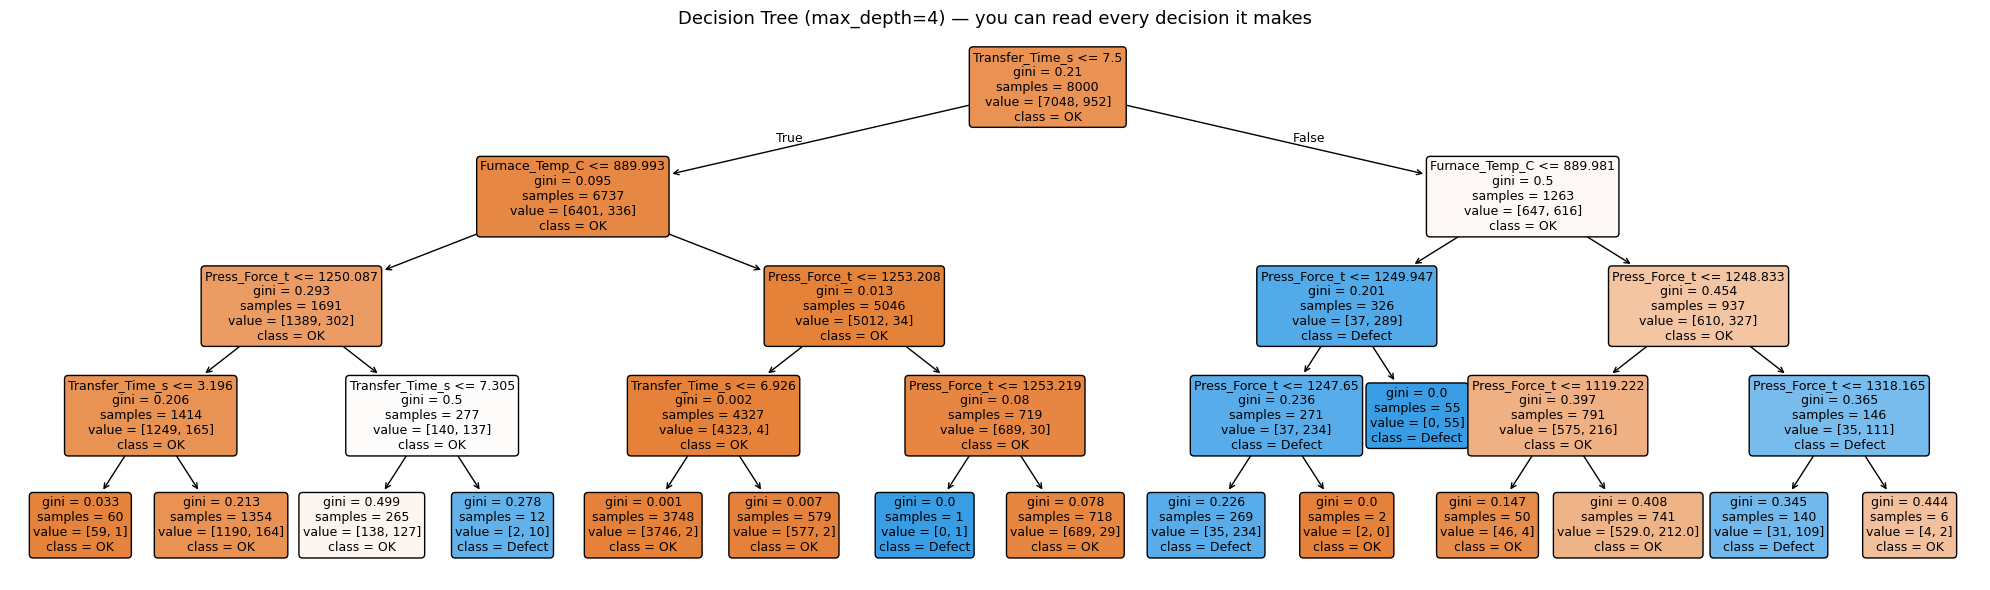

In [62]:
# --- Controlled tree (max_depth=4) ---
tree_model = DecisionTreeClassifier(max_depth=4, random_state=random_seed)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("=" * 53)
print("DECISION TREE (max_depth=4)")
print("=" * 53)
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree)*100:.2f}%")
print()
print(classification_report(y_test, y_pred_tree, target_names=['OK', 'Defect']))

# Visualise the tree
plt.figure(figsize=(20, 6))
plot_tree(
    tree_model, feature_names=X.columns.tolist(),
    class_names=['OK', 'Defect'], filled=True, rounded=True, fontsize=9
)
plt.title("Decision Tree (max_depth=4)", fontsize=13)
plt.tight_layout()
plt.show()

In [63]:
# --- Demonstrating Overfitting ---
# What happens when we remove the depth limit?

tree_overfit = DecisionTreeClassifier(max_depth=None, random_state=random_seed)  # no limit!
tree_overfit.fit(X_train, y_train)

train_acc = accuracy_score(y_train, tree_overfit.predict(X_train))
test_acc  = accuracy_score(y_test,  tree_overfit.predict(X_test))

print("=" * 55)
print("OVERFITTING DEMONSTRATION")
print("=" * 55)
print(f"Unlimited tree — Training accuracy:  {train_acc*100:.2f}%  ← memorised the training data")
print(f"Unlimited tree — Test accuracy:      {test_acc*100:.2f}%   ← performs worse on new parts")
print()
print(f"Controlled tree (depth=4) — Test accuracy: {accuracy_score(y_test, y_pred_tree)*100:.2f}%")
print()
print("""
CONCLUSION:
The unlimited tree memorised the noise in the training data. It learned
the quirks of those 8,000 parts, not the general rules that apply to all parts.
max_depth is a constraint we add deliberately to force the model to generalise.
This trade-off between fitting training data and generalising is called the
bias-variance trade-off and it is one of the most important concepts in ML.
""")

OVERFITTING DEMONSTRATION
Unlimited tree — Training accuracy:  100.00%  ← memorised the training data
Unlimited tree — Test accuracy:      88.15%  ← performs worse on new parts

Controlled tree (depth=4) — Test accuracy: 92.35%


CONCLUSION:
The unlimited tree memorised the noise in the training data — it learned
the quirks of those 8,000 parts, not the general rules that apply to all parts.
max_depth is a constraint we add deliberately to force the model to generalise.
This trade-off between fitting training data and generalising is called the
bias-variance trade-off — one of the most important concepts in ML.



## Step 7: Random Forest
Instead of one decision tree, we build **100 different trees**. Each tree is trained on a slightly different random sample of your data (this is known as "bootstrap sampling") and considers a random subset of sensors at each split.

At prediction time, all 100 trees vote. The majority wins.

This approach — combining many imperfect models into one robust one is known as **ensemble learning**. The individual trees overfit in different directions, and their errors cancel out. Therefore, the random forest algorithm reduces risk for overfitting. In the end, you get better accuracy, but you can no longer draw one flowchart and read every decision.

RANDOM FOREST (100 trees)
Accuracy: 91.65%

              precision    recall  f1-score   support

          OK       0.94      0.97      0.95      1781
      Defect       0.66      0.48      0.56       219

    accuracy                           0.92      2000
   macro avg       0.80      0.73      0.76      2000
weighted avg       0.91      0.92      0.91      2000



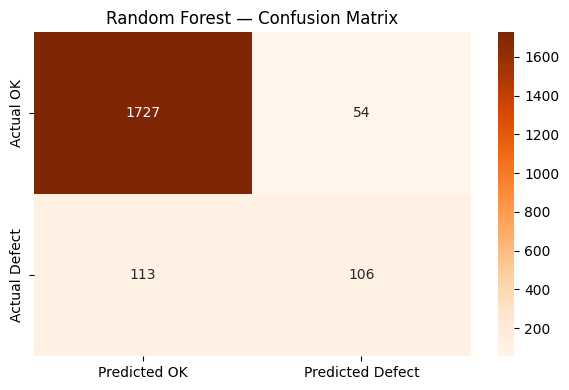


HOW TO READ THE CONFUSION MATRIX:

  Top-left  (True Negative):  Parts correctly identified as OK
  Top-right (False Positive): OK parts incorrectly flagged as defective  → false alarm, wasted scrap
  Bot-left  (False Negative): Defective parts missed by the model        → danger, escapes to customer
  Bot-right (True Positive):  Defects correctly caught                   → the goal



In [67]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=random_seed)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=" * 53)
print("RANDOM FOREST (100 trees)")
print("=" * 53)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print()
print(classification_report(y_test, y_pred_rf, target_names=['OK', 'Defect']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Predicted OK', 'Predicted Defect'],
    yticklabels=['Actual OK', 'Actual Defect']
)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

print("""
HOW TO READ THE CONFUSION MATRIX:

  Top-left  (True Negative):  Parts correctly identified as OK           → the goal
  Top-right (False Positive): OK parts incorrectly flagged as defective  → false alarm, wasted scrap
  Bot-left  (False Negative): Defective parts missed by the model        → danger, escapes to customer
  Bot-right (True Positive):  Defects correctly caught                   → the goal
""")

## Step 8: Model Comparison
Throughout this notebook we have tried a couple of models; logistic regression, decision tree, and random forest. It is time to compare the models and determine which one, if any, we shall go with. We decide to compare the models based on _F1 score_, _recall score_, and _precision score_.

In [72]:
from sklearn.metrics import f1_score, recall_score, precision_score

results = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree':       y_pred_tree,
    'Random Forest':       y_pred_rf,
}

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1':>7}")
print("=" * 66)
for name, preds in results.items():
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    print(f"{name:<25} {acc*100:>9.2f}% {prec*100:>10.2f}% {rec*100:>8.2f}% {f1*100:>6.2f}%")

print("""
DISCUSSION POINTS:
- Which metric matters most for this use case?
- If you had to choose one model to put on the production line today, which would it be and why?
""")

Model                       Accuracy   Precision    Recall      F1
Logistic Regression           89.80%      59.04%    22.37%  32.45%
Decision Tree                 92.35%      81.13%    39.27%  52.92%
Random Forest                 91.65%      66.25%    48.40%  55.94%

DISCUSSION POINTS:
- Which metric matters most for this use case?
- If you had to choose one model to put on the production line today, which would it be and why?



## Step 9: What is Driving the Defects?

The Random Forest can tell us which sensors it relied on most when making decisions.
This is called **feature importance**, which is the insight we sought all along.

A high importance score means that sensor was frequently useful for separating defective parts from OK ones.

Top parameters by importance:
  Transfer_Time_s       : 39.6%
  Furnace_Temp_C        : 26.2%
  Press_Force_t         : 20.2%
  Cooling_Flow_Lpm      : 14.0%

ENGINEERING ACTION:
The model has quantified which parameters to focus on.
If Transfer_Time_s appears at the top, your priority is reducing transfer time variance.
If Furnace_Temp_C is dominant, focus on furnace temperature stability.



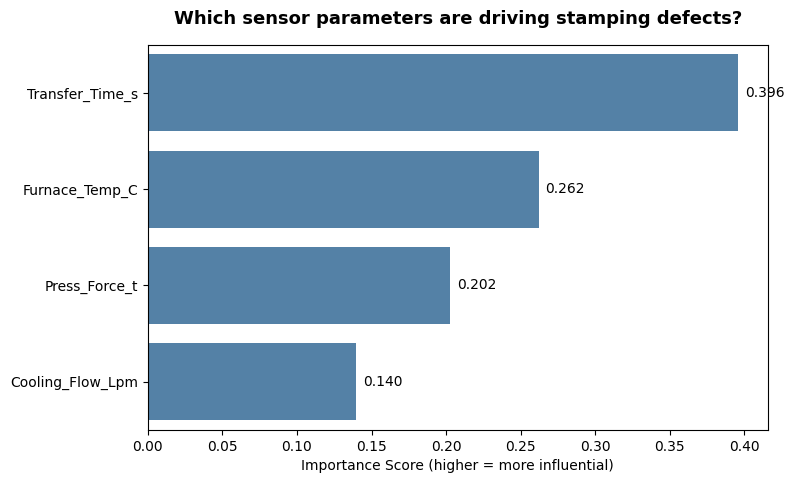

In [84]:
importances   = rf_model.feature_importances_
feature_names = X.columns
sorted_idx    = np.argsort(importances)

y_labels = [feature_names[i] for i in sorted_idx][::-1]
x_values = importances[sorted_idx][::-1]

plt.figure(figsize=(8, 5))

# Create the horizontal bar plot
ax = sns.barplot(
    x=x_values,
    y=y_labels,
    color='steelblue'  # Applying a single color rather than a palette
)

# Optional but highly recommended: Add the exact values to the end of each bar
ax.bar_label(ax.containers[0], fmt='%.3f', padding=5)

plt.title("Which sensor parameters are driving stamping defects?", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Importance Score (higher = more influential)")
plt.ylabel("") # Clears the y-axis label since the feature names are self-explanatory

print("Top parameters by importance:")
for i in sorted_idx[::-1]:
    print(f"  {feature_names[i]:<22}: {importances[i]*100:.1f}%")

print("""
ENGINEERING ACTION:
The model has quantified which parameters to focus on. What would be your priority
based on these results? What would be of lower priority to investigate/update?
""")

## Step 10: Put the Model to Work: Predict a New Part

A part has just come off the press. The sensors recorded the following readings.
Would you pass it or scrap it?

In [90]:
# Sensor readings from a part that just came off the press
new_part = pd.DataFrame([{
    'Furnace_Temp_C':   885,   # Low  - below normal operating range
    'Transfer_Time_s':  8.1,   # High - steel cooled significantly before pressing
    'Press_Force_t':    1260,  # High - excess force on a partially cooled blank
    'Cooling_Flow_Lpm': 41.0   # Normal
}])
print("NEW PART:")
display(new_part)

# Predict with random forest model:
prediction   = rf_model.predict(new_part)[0]
probability  = rf_model.predict_proba(new_part)[0]

print()
print("=" * 40)
if prediction == 1:
    print("⚠️ PREDICTION: DEFECT — SCRAP THIS PART")
else:
    print("✅  PREDICTION: OK — PASS")
print(f"   Probability of OK:     {probability[0]*100:.1f}%")
print(f"   Probability of Defect: {probability[1]*100:.1f}%")
print("=" * 40)
print()
print("""
Note: the model also gives us a probability, not just a binary call.
In practice you can tune the threshold, e.g. flag anything above 30% probability
as defective, if the cost of a missed defect is high. This should be fine-tuned
according to domain knowledge.
""")

NEW PART:


,Furnace_Temp_C,Transfer_Time_s,Press_Force_t,Cooling_Flow_Lpm
0,885,8.1,1260,41.0



⚠️ PREDICTION: DEFECT — SCRAP THIS PART
   Probability of OK:     2.0%
   Probability of Defect: 98.0%


Note: the model also gives us a probability, not just a binary call.
In practice you can tune the threshold, e.g. flag anything above 30% probability
as defective, if the cost of a missed defect is high. This should be fine-tuned 
according to domain knowledge.



### Before putting any model into production, you would also need to:
- **Validate on real data**: synthetic data is optimistic; expect lower accuracy and more tuning
- **Monitor for drift**: as tooling wears or materials change, the model needs retraining
- **Set the threshold deliberately**: don't accept the default 50% cutoff; tune it to your cost trade-offs
- **Involve quality and safety engineers**: the model is a tool to support decisions, not replace them